# **RFscorer チュートリアル 初級編 (日本語)**

このノートブックでは `rfscorer` の基本的なワークフローを説明します：

1. パッケージの読み込み
2. 行動履歴の読み込み
3. 行動履歴を訓練データとテストデータへ分割
4. 訓練データを観測データと正解データへ分割
5. 経験(emp)モデルの構築（`fit`）と経験的商品選択確率の可視化
6. 単調(mono)モデルの構築（`optimize(kind="mono")`）と最適化商品選択確率の可視化
7. 単調凹凸(mcc)モデルの構築（`optimize(kind="mcc")`）と最適化商品選択確率の可視化
8. 予測(`transform()`)による商品選択確率と推薦順位の付与
9. 予測精度の評価（`evaluate()`）を行い、推薦結果レポートを作成
10. モデルの保存とロード（`save()` / `load()`）

---
## **1.パッケージの読み込み**
はじめに必要なパッケージを読み込みます。
`RecencyFrequencyScorer`はRFスコアリングを行うクラスで、`split_by_date`はデータセットを観測データと正解データに分割するユーティリティ関数です。

In [1]:
# Google Colab で実行する場合は、以下の行のコメントを外して rfscorer をインストールしてください：
# !pip install rfscorer

import pandas as pd

from rfscorer import RecencyFrequencyScorer, split_by_date

---
## **2. 行動履歴の読み込み**
次に行動履歴を読み込み、列名をデフォルトの列名（`user_col='user'`, `item_col='item'`, `time_col='datetime'`）に変更します。
行動履歴の各行は「ユーザーが商品を閲覧（接触）した記録」を表し、同一ユーザーが同じ商品を複数回閲覧することを前提としています。

> `access_log.csv` は [ohmsha/PyOptBook](https://github.com/ohmsha/PyOptBook/tree/main/7.recommendation) から
> (MIT License)

In [2]:
url = "https://raw.githubusercontent.com/ohmsha/PyOptBook/main/7.recommendation/access_log.csv"
df = pd.read_csv(url)
df.columns = ["user", "item", "datetime"]

print("record num:", len(df))
print("user num:", len(df.user.unique()))
print("item num:", len(df.item.unique()))
df.head()

record num: 325908
user num: 31443
item num: 87611


,user,item,datetime
0,4,205587,2015-07-04
1,4,748683,2015-07-04
2,4,790055,2015-07-04
3,4,790055,2015-07-04
4,4,764638,2015-07-04


---
## **3. 訓練データとテストデータへ分割**

本チュートリアルでは、ハッシュベースの分割を使用して、ユーザーを訓練データ（80%）とテストデータ（20%）に分割します。

In [3]:
df_train = df[df.user.map(lambda x: hash(x) % 10 < 8)]
df_test = df[df.user.map(lambda x: hash(x) % 10 >= 8)]

print("train record num:", len(df_train), "/ user num:", len(df_train.user.unique()))
print("test  record num: ", len(df_test), "/ user num: ", len(df_test.user.unique()))

train record num: 264272 / user num: 25316
test  record num:  61636 / user num:  6127


---
## **4. 訓練データを観測データと正解データへ分割**
訓練データを観測期間（target_date 以前7日間）と正解期間（target_date 翌日以降1日間）に分割し、観測データと正解データを作成します。

In [4]:
target_date = "2015-07-07"
df_train_obs, df_train_gt = split_by_date(df_train, target_date, observation_days=7, gt_days=1)

---
## **5. 経験(emp)モデルの構築（`fit`）と経験的商品選択確率の可視化**

観測データと正解データを`fit()` に渡してモデル構築をします。
観測データから最新度と頻度が計算され、正解データの商品選択（再閲覧・購買・CV など）を紐づけて集計することで、経験的商品選択確率を計算します。

In [5]:
scorer = RecencyFrequencyScorer()
scorer.fit(df_train_obs, df_train_gt)
scorer.show()

=== RecencyFrequencyScorer ===

── Data ──────────────────────────────────────────────
  dataset          : obs 232157 rows,  gt 32115 events  (users: 23058,  items: 71253)
  observation      : 2015-07-01 → 2015-07-07
  user×item pairs  : 165833 → 165134  (before → after applying limits)
  target events    : 1783 → 1712  (before → after applying limits)

── Model ─────────────────────────────────────────────
  recency_limit    : 7
  frequency_limit  : 8

── Correlation ───────────────────────────────────────
  [expected: recency ρ < 0  (more recent → higher prob),
             frequency ρ > 0  (more frequent → higher prob)]
  recency  ρ       : -1.0000  (p=0.0000,  n=7,  weighted ρ: -1.0000)
  frequency ρ      :  0.9762  (p=0.0000,  n=8,  weighted ρ:  0.9948)

  Slice ρ by r  [corr(f, P(r,f)),  expected > 0]
    r= 1:   0.9674
    r= 2:   0.9829
    r= 3:   0.9161
    r= 4:   0.8763
    r= 5:   0.8946
    r= 6:   0.7849
    r= 7:   0.8119
  Slice ρ by f  [corr(r, P(r,f)),  expected < 0

さらに、経験的商品選択確率を3次元ワイヤーフレームとしてプロットします。
最新度はx軸に沿って増加し（1 = 最も新しい）、頻度はy軸に沿って増加します。

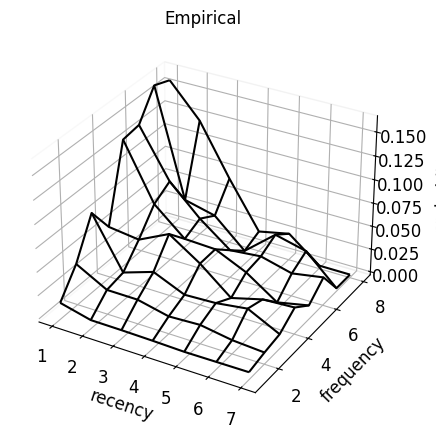

In [6]:
fig_emp = scorer.plot_probability_surface(kind="emp")

---
## **6. 単調(mono)モデルの構築（`optimize(kind="mono")`）と最適化商品選択確率の可視化**

`kind='mono'` は、商品選択確率が最新度について単調減少（Recency 制約）で、頻度について単調増加（Frequency 制約）することを強制します。

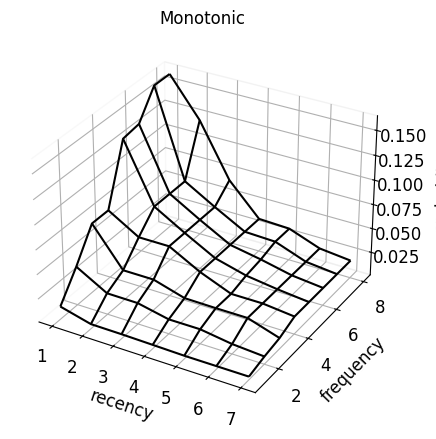

In [7]:
scorer.optimize(kind="mono")
fig_mono = scorer.plot_probability_surface(kind="mono")

---
## **7. 単調凹凸(mcc)モデルの構築（`optimize(kind="mcc")`）と最適化商品選択確率の可視化**

`kind='mcc'` は、Recency 凸性と Frequency 凹性を追加で課し、より滑らかな3次元ワイヤーフレームを生成します。

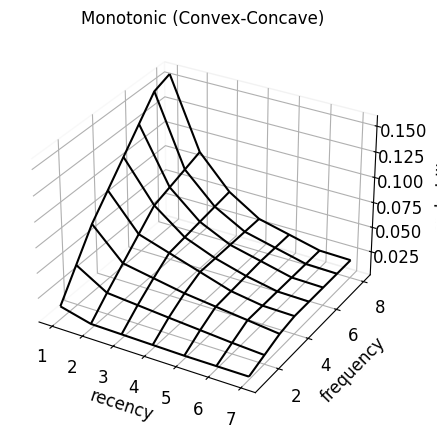

In [8]:
scorer.optimize(kind="mcc")
fig_mcc = scorer.plot_probability_surface(kind="mcc")

---
## **8. 予測(`transform()`)による商品選択確率と推薦順位の付与**

推薦スコアを付与する前に、テストデータを`target_date`を基準に、観測データと正解データに分割します。
`transform()` は各ユーザー-商品ペアに対し、`target_date` に対する最新度と頻度・商品選択確率・推薦順位を付与します。
推薦結果のデータフレームは、各ユーザー内において `probability` で降順にソートされ、`order` は推薦順位を表します。

In [9]:
df_test_obs, df_test_gt = split_by_date(df_test, target_date, observation_days=7, gt_days=1)

# 単調凹凸(mcc)モデルを用いた予測(単調(mono)モデルや経験(emp)モデルも指定可能)
df_rec = scorer.transform(df_test_obs, target_date, kind="mcc")
df_rec.head(10)

,user,item,recency,frequency,probability,order
9190,100099,311656,4,1,0.005005,1
9191,100099,411961,4,1,0.005005,2
9192,100129,353070,5,4,0.024996,1
9196,100138,591186,6,4,0.020066,1
9193,100138,852831,6,3,0.020066,2
9194,100138,1111746,6,2,0.012395,3
9197,100138,81286,2,1,0.006113,4
9198,100138,587992,2,1,0.006113,5
9199,100138,686685,2,1,0.006113,6
9200,100138,328892,2,1,0.006113,7


---
## **9. 予測精度の評価（`evaluate()`）を行い、推薦結果レポートを作成**

`evaluate()` に推薦結果のデータフレームとテストデータから得られた正解データを与えます。
各推薦順位のカットオフで 適合率(`precision`)、再現率(`recall`)、F1値(`f1`) などの評価指標を出力します。

また、観測期間に各ユーザーが閲覧した全商品を推薦した場合に再現率が1.0になるように正規化した評価指標を`recall_norm`とし、`precision`と`recall_norm`から計算された正規化されたF1値を`f1_norm`とします。

In [10]:
scorer.evaluate(df_rec, df_test_gt, order=5)

,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,5547,104,0.018749,0.018009,0.018371,0.280323,0.035147
1,2,10583,166,0.015686,0.028745,0.020296,0.447439,0.030309
2,3,14336,209,0.014579,0.036190,0.020785,0.563342,0.028422
3,4,17322,240,0.013855,0.041558,0.020782,0.646900,0.027129
4,5,19742,261,0.013221,0.045195,0.020457,0.703504,0.025953
5,195,38828,371,0.009555,0.064242,0.016636,1.000000,0.018929


---
## **10. モデルの保存とロード**

`fit()` と `optimize()` で構築したモデルはインスタンス内に保存されています。
`save()` でファイルに書き出しておくことで、次回以降は `load()` でロードするだけでスコアリングに利用できます。
再学習のコストを省けるため、サーバーへのデプロイにも適しています。

引数なしで呼ぶとカレントディレクトリに `rfscorer.pkl` が作成されます。

In [11]:
# モデルを保存（カレントディレクトリに rfscorer.pkl）
scorer.save()

# ロードして動作確認
scorer_loaded = RecencyFrequencyScorer.load("rfscorer.pkl")
scorer_loaded.predict(1, 1, kind="mcc")

0.014041659327068277

### Google Colab をご利用の場合

```python
from google.colab import drive
drive.mount("/content/drive")

scorer.save("/content/drive/MyDrive/rfscorer.pkl")
```